# Urban Cooling Inefficiency Detection — Dhaka, Bangladesh (2025)
## Convolutional Neural Network using TensorFlow / Keras

**Study Area:** Dhaka Metropolitan Region (90.25–90.55°E, 23.68–23.93°N)  
**Inputs:** 32×32 pixel patches — NDVI, NDBI, LST_C (Landsat-9, 2025)  
**Target:** Binary classification  
- `0` = Efficient Cooling  
- `1` = Cooling Inefficiency (high vegetation + high LST)  

**Key improvements over basic CNN:**
- ✅ Class weights (handles imbalanced labels)
- ✅ Multiple threshold testing (0.40 – 0.55)
- ✅ ModelCheckpoint (saves best val_loss model)
- ✅ Auto-selects best threshold by class-1 F1-score

## Step 1: Install Required Libraries

In [4]:
!pip install tensorflow rasterio scikit-learn pandas numpy matplotlib

## Step 2: Import Libraries

In [12]:
import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Step 3. Define File Paths and Model Settings

In [14]:


raster_path     = r"C:\Users\nurmd\Downloads\Inefficiency\Dhaka_DL_Stack_With_Label_ALL_2025.tif"
csv_path        = r"C:\Users\nurmd\Downloads\Inefficiency\Dhaka_Patch_Centers_With_Labels_ALL_2025.csv"
model_save_path = r"C:\Users\nurmd\Downloads\Inefficiency\dhaka_cnn_model.keras"
threshold_csv_path = r"C:\Users\nurmd\Downloads\Inefficiency\threshold_comparison_results.csv"

## Step 4. Model Settings

In [16]:
patch_size   = 32
half_patch   = patch_size // 2
random_state = 42
test_size    = 0.2
val_size     = 0.2
batch_size   = 32
epochs       = 20

thresholds_to_test = [0.40, 0.45, 0.50, 0.55]

print("Settings ready.")
print("patch_size:", patch_size)
print("half_patch:", half_patch)

Settings ready.
patch_size: 32
half_patch: 16


## Step 5: Load and Inspect Patch Centre CSV

The CSV contains geographic coordinates (`longitude`, `latitude`) of 32×32 patch centres
and a binary `label` column assigned by rule-based thresholds in Google Earth Engine:

- **Label 0** — Efficient Cooling
- **Label 1** — Cooling Inefficiency 

In [18]:
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

# Validate required columns
for col in ["longitude", "latitude", "label"]:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

df = df.dropna(subset=["longitude", "latitude", "label"]).copy()
df["label"] = df["label"].astype(int)

if df["label"].nunique() < 2:
    raise ValueError("Only one class found — cannot train binary classifier.")

print("CSV shape:", df.shape)
print("\nLabel distribution:")
print(df["label"].value_counts())
print(f"\nClass imbalance ratio: {df['label'].value_counts()[0] / df['label'].value_counts()[1]:.2f}:1")
df.head()

CSV shape: (4704, 8)

Label distribution:
label
0    3937
1     767
Name: count, dtype: int64

Class imbalance ratio: 5.13:1


,system:index,LST_C,NDBI,NDVI,label,latitude,longitude,.geo
0,0_0,30.332540,-0.041402,0.312686,0,23.686283,90.464616,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,1_0,32.779842,-0.182270,0.611540,1,23.832080,90.365981,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,2_0,31.735638,-0.180213,0.538286,0,23.760933,90.461652,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,3_0,33.352360,0.028894,0.251870,0,23.702723,90.422036,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,4_0,34.222248,-0.091711,0.488287,1,23.760394,90.380264,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


## Step 6: Load GeoTIFF Raster Stack

The 4-band GeoTIFF was exported from Google Earth Engine:

| Band | Variable | Role |
|------|----------|------|
| 1 | NDVI | CNN input |
| 2 | NDBI | CNN input |
| 3 | LST_C | CNN input |
| 4 | label | **NOT used as input** (verification only) |

In [19]:
with rasterio.open(raster_path) as src:
    raster        = src.read()
    transform     = src.transform
    crs           = src.crs
    raster_height = src.height
    raster_width  = src.width
    band_count    = src.count

print("\nRaster shape (bands, rows, cols):", raster.shape)
print("Raster CRS:", crs)
print("Raster size:", raster_width, "x", raster_height)
print("Band count:", band_count)

if band_count < 3:
    raise ValueError("Raster must contain at least 3 bands (NDVI, NDBI, LST_C).")

# Use only first 3 bands as predictors
# Band 1 = NDVI, Band 2 = NDBI, Band 3 = LST_C
# Band 4 = label (DO NOT USE as predictor)
predictor_raster = raster[:3, :, :]


Raster shape (bands, rows, cols): (4, 928, 1114)
Raster CRS: EPSG:4326
Raster size: 1114 x 928
Band count: 4


## Step 7: Extract 32×32 Pixel Patches

For each patch centre coordinate, a 32×32 window is extracted from the raster stack.  
Patches are skipped if they:
- Fall within 16 pixels of the raster edge
- Contain any `NaN` values

In [20]:
X_patches = []
y_labels  = []

skipped_edge = 0
skipped_nan  = 0
used_count   = 0

with rasterio.open(raster_path) as src:
    for _, row in df.iterrows():
        lon   = row["longitude"]
        lat   = row["latitude"]
        label = int(row["label"])

        try:
            r, c = src.index(lon, lat)
        except Exception:
            continue

        r0 = r - half_patch
        r1 = r + half_patch
        c0 = c - half_patch
        c1 = c + half_patch

        # Skip edge cases
        if r0 < 0 or c0 < 0 or r1 > raster_height or c1 > raster_width:
            skipped_edge += 1
            continue

        patch = predictor_raster[:, r0:r1, c0:c1]  # shape: (3, 32, 32)

        # Check exact shape
        if patch.shape != (3, patch_size, patch_size):
            skipped_edge += 1
            continue

        # Skip if patch has NaN
        if np.isnan(patch).any():
            skipped_nan += 1
            continue

        # Convert to channel-last for TensorFlow: (32, 32, 3)
        patch = np.transpose(patch, (1, 2, 0))

        X_patches.append(patch.astype(np.float32))
        y_labels.append(label)
        used_count += 1

X = np.array(X_patches, dtype=np.float32)
y = np.array(y_labels,  dtype=np.int32)

print("\nPatch extraction finished")
print("Used patches:", used_count)
print("Skipped edge:", skipped_edge)
print("Skipped NaN:",  skipped_nan)
print("X shape:", X.shape)
print("y shape:", y.shape)

if len(X) == 0:
    raise ValueError("No valid patches were extracted. Check raster/CSV alignment.")


Patch extraction finished
Used patches: 4704
Skipped edge: 0
Skipped NaN: 0
X shape: (4704, 32, 32, 3)
y shape: (4704,)


## Step 8: Per-Channel Z-Score Normalisation

Each of the 3 input channels (NDVI, NDBI, LST_C) is independently normalised:

$$x_{norm} = \frac{x - \mu}{\sigma}$$

This prevents LST (range ~20–45°C) from dominating NDVI (range −1 to 1) during training.

In [21]:
X_norm         = X.copy()
channel_names  = ["NDVI", "NDBI", "LST_C"]

for ch in range(3):
    mu  = X_norm[:, :, :, ch].mean()
    sig = X_norm[:, :, :, ch].std()
    if sig == 0:
        sig = 1.0
    X_norm[:, :, :, ch] = (X_norm[:, :, :, ch] - mu) / sig
    print(f"  {channel_names[ch]:6s} → mean = {mu:.4f}, std = {sig:.4f}")

  NDVI   → mean = 0.4130, std = 0.1717
  NDBI   → mean = -0.1168, std = 0.1394
  LST_C  → mean = 31.5208, std = 2.2227


## Step 9: Split Data into Training, Validation, and Test Sets

| Split | Fraction | Purpose |
|-------|----------|---------|
| Train | 64 % | Model weight updates |
| Validation | 16 % | Early stopping, hyperparameter tuning |
| Test | 20 % | Final unbiased evaluation |

Stratified splitting preserves the class ratio in all three subsets.

In [25]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_norm,
    y,
    test_size=test_size,
    random_state=random_state,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=val_size,
    random_state=random_state,
    stratify=y_trainval
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (3010, 32, 32, 3) (3010,)
Validation shape: (753, 32, 32, 3) (753,)
Test shape: (941, 32, 32, 3) (941,)


## Step 10: Compute Class Weights

The dataset is imbalanced (~85 % class 0, ~15 % class 1).  
Without correction, the model biases toward predicting class 0 for every patch.  
`sklearn` computes balanced weights inversely proportional to class frequency:

$$w_c = \frac{N}{k \cdot N_c}$$

where $N$ = total samples, $k$ = number of classes, $N_c$ = samples in class $c$.

In [27]:
classes      = np.unique(y_train)
weights_arr  = compute_class_weight(class_weight="balanced",
                                     classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights_arr)}

print("Class weights:", class_weight_dict)
print(f"  Class 0 (Efficient)     weight = {class_weight_dict[0]:.4f}")
print(f"  Class 1 (Inefficiency)  weight = {class_weight_dict[1]:.4f}")

Class weights: {0: 0.5974593092497023, 1: 3.065173116089613}
  Class 0 (Efficient)     weight = 0.5975
  Class 1 (Inefficiency)  weight = 3.0652


## 11. Build CNN Model

The CNN uses three convolutional blocks followed by a dense classifier.  
The final sigmoid layer produces the probability of cooling inefficiency.


In [29]:
def build_model(input_shape=(patch_size, patch_size, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## Step 12: Train the Model

Two callbacks are used:
- **EarlyStopping** — stops training if `val_loss` does not improve for 5 epochs; restores best weights
- **ModelCheckpoint** — saves the model whenever `val_loss` improves

For want to strict in the same result for the newly train model on the same database, use: **shuffle=False**, inside the **history**

In [32]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=model_save_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6847 - loss: 0.5805
Epoch 1: val_loss improved from None to 0.44891, saving model to C:\Users\nurmd\Downloads\Inefficiency\dhaka_cnn_model.keras

Epoch 1: finished saving model to C:\Users\nurmd\Downloads\Inefficiency\dhaka_cnn_model.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7482 - loss: 0.4976 - val_accuracy: 0.7902 - val_loss: 0.4489
Epoch 2/20
89/95 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7796 - loss: 0.4199
Epoch 2: val_loss did not improve from 0.44891
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7957 - loss: 0.4100 - val_accuracy: 0.7623 - val_loss: 0.4646
Epoch 3/20
88/95 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8399 - loss: 0.3677
Epoch 3: val_loss improved from 0.44891 to 0.36639, saving model to C:\Users\nurmd\Downloads\Inefficiency\dhaka_cnn_model.keras

Epoch 3: finished saving model to C:\Users\nurmd\Downloads\Inefficiency\dhaka_cnn_model.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 

## Step 13. Load Best Model and Predict Test Probabilities

In [39]:
paper_model_path = r"C:\Users\nurmd\Downloads\Inefficiency agit 26\dhaka_cnn_model.keras"

best_model = tf.keras.models.load_model(
    paper_model_path
)

print("\nFinal paper model loaded:")
print(paper_model_path)

y_prob = best_model.predict(X_test).ravel()


Final paper model loaded:
C:\Users\nurmd\Downloads\Inefficiency agit 26\dhaka_cnn_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


## Step 14. Test Multiple Classification Thresholds

Several probability thresholds are tested.  
The threshold with the highest F1-score for the cooling inefficiency class is selected.

In [40]:
threshold_results = []

print("\n===== THRESHOLD COMPARISON =====")

for threshold in thresholds_to_test:
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred,
        average='binary',
        zero_division=0
    )

    threshold_results.append({
        "threshold":        threshold,
        "accuracy":         acc,
        "precision_class1": precision,
        "recall_class1":    recall,
        "f1_class1":        f1
    })

    print(
        f"Threshold {threshold:.2f} | "
        f"Accuracy: {acc:.4f} | "
        f"Precision(1): {precision:.4f} | "
        f"Recall(1): {recall:.4f} | "
        f"F1(1): {f1:.4f}"
    )

threshold_df = pd.DataFrame(threshold_results)
print("\nThreshold results table:")
print(threshold_df)

# Choose best threshold by class-1 F1
best_row       = threshold_df.loc[threshold_df["f1_class1"].idxmax()]
best_threshold = float(best_row["threshold"])

print(f"\nBest threshold by class-1 F1: {best_threshold:.2f}")


===== THRESHOLD COMPARISON =====
Threshold 0.40 | Accuracy: 0.8395 | Precision(1): 0.5037 | Recall(1): 0.8824 | F1(1): 0.6413
Threshold 0.45 | Accuracy: 0.8523 | Precision(1): 0.5282 | Recall(1): 0.8562 | F1(1): 0.6534
Threshold 0.50 | Accuracy: 0.8704 | Precision(1): 0.5708 | Recall(1): 0.8170 | F1(1): 0.6720
Threshold 0.55 | Accuracy: 0.8842 | Precision(1): 0.6111 | Recall(1): 0.7908 | F1(1): 0.6895

Threshold results table:
   threshold  accuracy  precision_class1  recall_class1  f1_class1
0       0.40  0.839532          0.503731       0.882353   0.641330
1       0.45  0.852285          0.528226       0.856209   0.653367
2       0.50  0.870351          0.570776       0.816993   0.672043
3       0.55  0.884166          0.611111       0.790850   0.689459

Best threshold by class-1 F1: 0.55


## Step 15. Final Model Evaluation

In [41]:
y_pred_final = (y_prob >= best_threshold).astype(int)

acc_final = accuracy_score(y_test, y_pred_final)
cm_final = confusion_matrix(y_test, y_pred_final)
report_final = classification_report(y_test, y_pred_final, digits=4)

print("Best threshold:", best_threshold)
print("Test accuracy:", round(acc_final, 4))

print("\nConfusion Matrix:")
print(cm_final)

print("\nClassification Report:")
print(report_final)

Best threshold: 0.55
Test accuracy: 0.8842

Confusion Matrix:
[[711  77]
 [ 32 121]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9569    0.9023    0.9288       788
           1     0.6111    0.7908    0.6895       153

    accuracy                         0.8842       941
   macro avg     0.7840    0.8466    0.8091       941
weighted avg     0.9007    0.8842    0.8899       941



## Step 16. Plot Training Accuracy and Loss

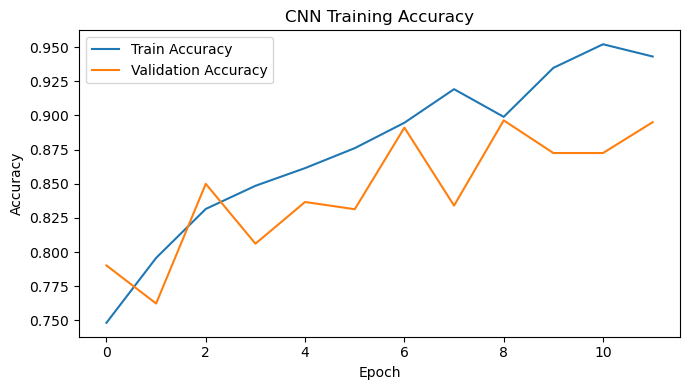

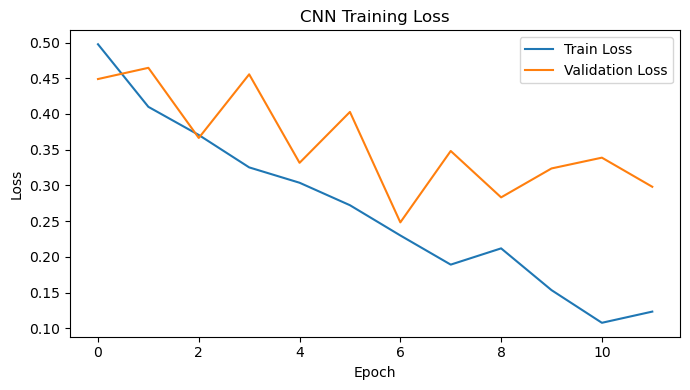

In [42]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")
plt.legend()
plt.tight_layout()
plt.show()

## Step 17. Plot Confusion Matrix

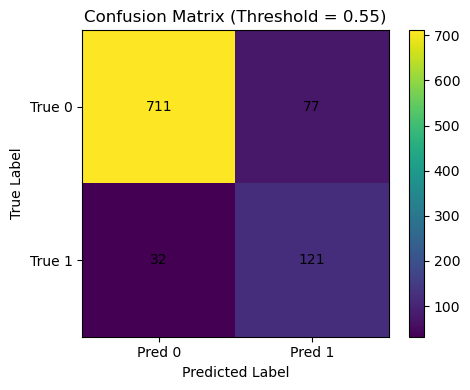

In [43]:
plt.figure(figsize=(5, 4))
plt.imshow(cm_final, interpolation="nearest")
plt.title(f"Confusion Matrix (Threshold = {best_threshold:.2f})")
plt.colorbar()

plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])

for i in range(cm_final.shape[0]):
    for j in range(cm_final.shape[1]):
        plt.text(j, i, str(cm_final[i, j]), ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## Step 18. Visualize Sample Test Patches

The NDVI channel is displayed for selected test patches.

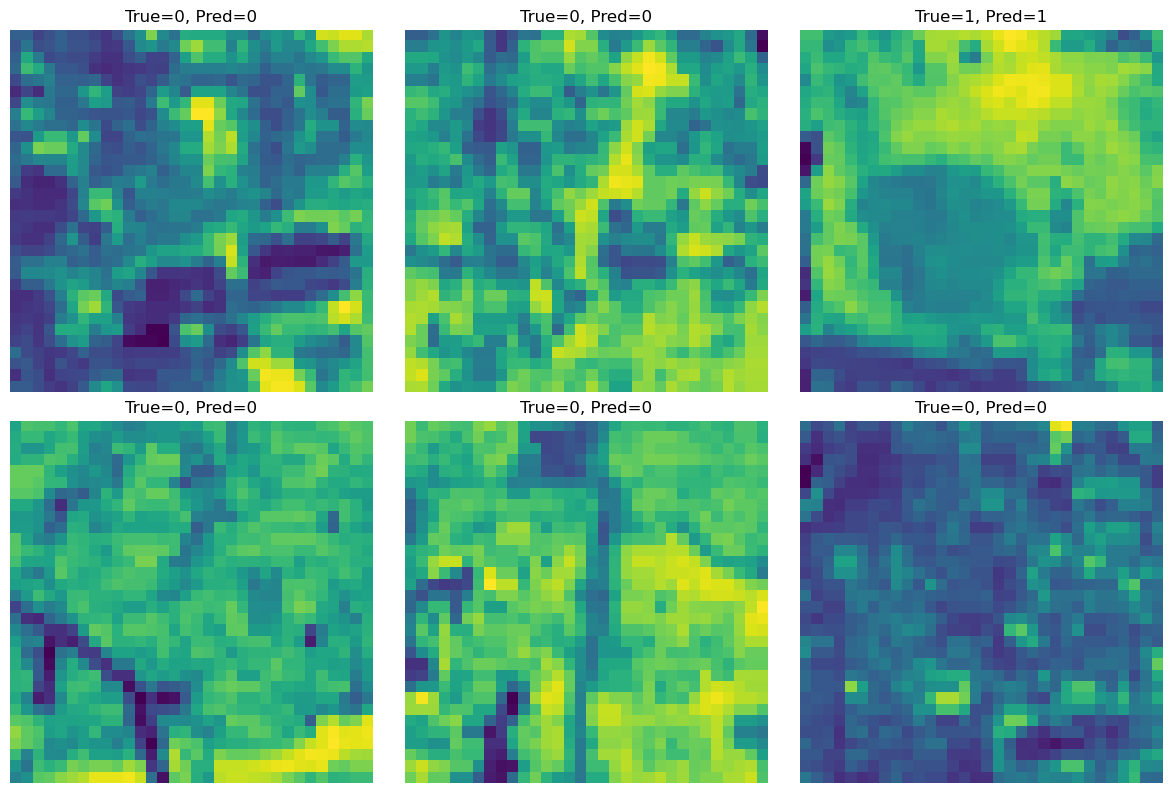

In [44]:
n_show = min(6, len(X_test))

plt.figure(figsize=(12, 8))

for i in range(n_show):
    plt.subplot(2, 3, i + 1)

    patch_img = X_test[i, :, :, 0]

    plt.imshow(patch_img)
    plt.title(f"True={y_test[i]}, Pred={y_pred_final[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 19. Save Threshold Comparison Results

In [45]:
threshold_df.to_csv(threshold_csv_path, index=False)

print("Threshold comparison saved to:")
print(threshold_csv_path)

print("Best CNN model saved to:")
print(model_save_path)

Threshold comparison saved to:
C:\Users\nurmd\Downloads\Inefficiency\threshold_comparison_results.csv
Best CNN model saved to:
C:\Users\nurmd\Downloads\Inefficiency\dhaka_cnn_model.keras
